In [1]:
from dimelo import parse_bam
from dimelo import plot_depth_profile, plot_enrichment_profile, plot_read_browser, plot_enrichment
from matplotlib import pyplot as plt

In [2]:
# import pysam
# fasta = pysam.FastaFile("/clusterfs/nilah/oberon/repos/rDNA-Mapping-Genomes/Human_hs1-rDNA_genome_v1.0/hs1-rDNA_v1.0.fa")
# print(fasta.references)

In [3]:
rRNAs =[
    "chr2:132689933-132691781",
    "chr20:29957342-29959194",
    "chr14:9674781-9676634",
    "chr15:15092341-15094209",
    "chr20:30928555-30930414",
]
PSMB2 = f"chr1:{35462557-5000}-{35504550+5000}"
PSMB2_known_pseu = "chr1	35466348"
tss_beds = [
    "/clusterfs/nilah/oberon/repos/multimodal-dimelo/data/processed/tss.gm12878_ranked.t2t_chm13v2.quartiles/q1.bed",
]
# tss_pileup,_ = parse_bam.pileup(
#     input_file="/global/scratch/projects/vector_streetslab/oberon/dRNA/RNA004_HEK293T_A/basecalled_m6A_pseU_redo.chm13v2.0.sorted.bam",
#     output_name="tss",
#     ref_genome="/clusterfs/nilah/oberon/repos/rDNA-Mapping-Genomes/Human_hs1-rDNA_genome_v1.0/hs1-rDNA_v1.0.fa",
#     regions=tss_beds,
#     window_size = 10_000,
#     motifs=["T,0,17802","A,0,a","DRACH,2,a","GTTC,2,17802","TSTAG,2,17802"],
#     thresh=0.98,
# )
tss_pileup="/global/scratch/projects/vector_streetslab/oberon/dRNA/RNA004_HEK293T_A/tss/pileup.sorted.bed.gz"
# psmb2_pileup,_ = parse_bam.pileup(
#     input_file="/global/scratch/projects/vector_streetslab/oberon/dRNA/RNA004_HEK293T_A/basecalled_m6A_pseU_redo.chm13v2.0.sorted.bam",
#     output_name="psmb2",
#     ref_genome="/clusterfs/nilah/oberon/genomes/chm13v2.0.fa",
#     regions=PSMB2,
#     motifs=["T,0,17802","A,0,a","DRACH,2,a","HRT,2,17802"],
#     thresh=0.75,
# )
psmb2_pileup="/global/scratch/projects/vector_streetslab/oberon/dRNA/RNA004_HEK293T_A/rrnas/pileup.sorted.bed.gz"
# psmb2_extract_nosplice,_ = parse_bam.extract(
#     input_file="/global/scratch/projects/vector_streetslab/oberon/dRNA/RNA004_HEK293T_A/basecalled_m6A_pseU_redo.chm13v2.0.sorted.bam",
#     output_name="psmb2_nosplice",
#     ref_genome="/clusterfs/nilah/oberon/genomes/chm13v2.0.fa",
#     regions=PSMB2,
#     motifs=["T,0,17802","A,0,a","DRACH,2,a","GTTC,2,17802","TSTAG,2,17802"],
#     cleanup=False,
# )
# psmb2_extract,_ = parse_bam.extract(
#     input_file="/global/scratch/projects/vector_streetslab/oberon/dRNA/RNA004_HEK293T_A/basecalled_m6A_pseU.splice.hs1-rDNA_v1.0.sorted.bam",
#     output_name="psmb2",
#     ref_genome="/clusterfs/nilah/oberon/repos/rDNA-Mapping-Genomes/Human_hs1-rDNA_genome_v1.0/hs1-rDNA_v1.0.fa",
#     regions=PSMB2,
#     motifs=["T,0,17802","A,0,a","DRACH,2,a","GTTC,2,17802","TSTAG,2,17802"],
#     cleanup=False,
# )
psmb2_extract = "/global/scratch/projects/vector_streetslab/oberon/dRNA/RNA004_HEK293T_A/psmb2/reads.combined_basemods.h5"
psmb2_extract_nosplice = "/global/scratch/projects/vector_streetslab/oberon/dRNA/RNA004_HEK293T_A/psmb2_nosplice/reads.combined_basemods.h5"
rrna_extract="/global/scratch/projects/vector_streetslab/oberon/dRNA/RNA004_HEK293T_A/rDNA_rrnas/reads.combined_basemods.h5"
rrna_extract_nosplice = "/global/scratch/projects/vector_streetslab/oberon/dRNA/RNA004_HEK293T_A/rDNA_rrnas_nosplice/reads.combined_basemods.h5"
# rrna_extract_nosplice, _ = parse_bam.extract(
#     input_file="/global/scratch/projects/vector_streetslab/oberon/dRNA/RNA004_HEK293T_A/basecalled_m6A_pseU_redo.hs1-rDNA_v1.0.sorted.bam",
#     output_name="rDNA_rrnas_nosplice",
#     ref_genome="/clusterfs/nilah/oberon/repos/rDNA-Mapping-Genomes/Human_hs1-rDNA_genome_v1.0/hs1-rDNA_v1.0.fa",
#     regions="chrR:0-44837",
#     motifs=["T,0,17802","A,0,a","DRACH,2,a","GTTC,2,17802","TSTAG,2,17802"],
# )
# rrna_extract, _ = parse_bam.extract(
#     input_file="/global/scratch/projects/vector_streetslab/oberon/dRNA/RNA004_HEK293T_A/basecalled_m6A_pseU.splice.hs1-rDNA_v1.0.sorted.bam",
#     output_name="rDNA_rrnas",
#     ref_genome="/clusterfs/nilah/oberon/repos/rDNA-Mapping-Genomes/Human_hs1-rDNA_genome_v1.0/hs1-rDNA_v1.0.fa",
#     regions="chrR:0-44837",
#     motifs=["T,0,17802","A,0,a","DRACH,2,a","GTTC,2,17802","TSTAG,2,17802"],
# )

In [33]:
# pileup, _ = parse_bam.pileup(
#     input_file="/global/scratch/projects/vector_streetslab/oberon/dRNA/RNA004_HEK293T_A/basecalled_m6A_pseU_redo.chm13v2.0.sorted.bam",
#     output_name="dorado_0.7.2",
#     ref_genome="/clusterfs/nilah/oberon/genomes/chm13v2.0.fa",
#     regions=["chr11:9_113_463-10_113_463"],
#     motifs=["T,0,17802","A,0,a","DRACH,2,a","HRT,2,17802","GTTC,2,17802","TSTAG,2,17802"],
#     thresh=0.98,
# )
chr1_R_pileup, _ = parse_bam.pileup(
    input_file="/global/scratch/projects/vector_streetslab/oberon/dRNA/RNA004_HEK293T_A/basecalled_m6A_pseU.splice.hs1-rDNA_v1.0.sorted.bam",
    output_name="chr1_R_pileup_spliced",
    ref_genome="/clusterfs/nilah/oberon/repos/rDNA-Mapping-Genomes/Human_hs1-rDNA_genome_v1.0/hs1-rDNA_v1.0.fa",
    regions=["chr1:0-248_387_328","chrR:0-44837"],
    motifs=["T,0,17802","A,0,a","DRACH,2,a","GTTC,2,17802","TSTAG,2,17802","TGTAG,2,17802","TGTAR,2,17802"],
    thresh=0.98,
)
chr1_R_pileup = "/global/scratch/projects/vector_streetslab/oberon/dRNA/RNA004_HEK293T_A/chr1_R_pileup_spliced/pileup.sorted.bed.gz"
# stop_codon_pileup, _ = parse_bam.pileup(
#     input_file="/global/scratch/projects/vector_streetslab/oberon/dRNA/RNA004_HEK293T_A/basecalled_m6A_pseU.splice.hs1-rDNA_v1.0.sorted.bam",
#     output_name="stop_codon_pileup_spliced",
#     ref_genome="/clusterfs/nilah/oberon/repos/rDNA-Mapping-Genomes/Human_hs1-rDNA_genome_v1.0/hs1-rDNA_v1.0.fa",
#     regions="/clusterfs/nilah/oberon/datasets/annotations/hs1_stop_codons_high_confidence.bed",
#     motifs=["T,0,17802","A,0,a","DRACH,2,a","GTTC,2,17802","TSTAG,2,17802"],
#     window_size=1500,
#     thresh=0.98,
# )
stop_codon_pileup = "/global/scratch/projects/vector_streetslab/oberon/dRNA/RNA004_HEK293T_A/stop_codon_pileup_spliced/pileup.sorted.bed.gz"
# extract, _ = parse_bam.extract(
#     input_file="/global/scratch/projects/vector_streetslab/oberon/dRNA/RNA004_HEK293T_A/basecalled_m6A_pseU_redo.chm13v2.0.sorted.bam",
#     output_name="dorado_0.7.2",
#     ref_genome="/clusterfs/nilah/oberon/genomes/chm13v2.0.fa",
#     regions=["chr11:9_500_000-9_800_000"],
#     motifs=["T,0,17802","HRT,2,17802","A,0,a","DRACH,2,a"],
# )
# extract_dimelo, _ = parse_bam.extract(
#     input_file="/clusterfs/nilah/oberon/datasets/dimelo-accessibility/bams/20240923_dimelo_access_background.dorado_v102_sup_v500_5mC_5hmC_v3_6mA_v3.trim.align.filtered.q10.bam",
#     output_name="unphased_chr1_chr11_extract",
#     ref_genome="/clusterfs/nilah/oberon/genomes/chm13v2.0.fa",
#     regions=["chr11:500_000-9_800_000"],
#     motifs=["A,0","GCH,1","WCG,1"],
#     override_checks=True,
# )
# extract_fiber, _ = parse_bam.extract(
#     input_file='/global/scratch/projects/vector_streetslab/oberon/datasets/vollger_mendelian/fiberseq_bams/GM12878_WGS.retagged.chm13v2.0.sorted.bam',
#     output_name="unphased_fiber_chr1_chr11_extract",
#     ref_genome="/clusterfs/nilah/oberon/genomes/chm13v2.0.fa",
#     regions=["chr11:9_500_000-9_800_000"],
#     motifs=["A,0","CG,0"],
#     override_checks=True,
# )
# pileup_dimelo, _ = parse_bam.pileup(
#     input_file="/clusterfs/nilah/oberon/datasets/dimelo-accessibility/bams/20240923_dimelo_access_background.dorado_v102_sup_v500_5mC_5hmC_v3_6mA_v3.trim.align.filtered.q10.bam",
#     output_name="unphased_chr1_chr11_pileup",
#     ref_genome="/clusterfs/nilah/oberon/genomes/chm13v2.0.fa",
#     regions=["chr11:500_000-9_800_000"],
#     motifs=["A,0","GCH,1","WCG,1"],
#     override_checks=True,
# )
# pileup_fiber, _ = parse_bam.pileup(
#     input_file='/global/scratch/projects/vector_streetslab/oberon/datasets/vollger_mendelian/fiberseq_bams/GM12878_WGS.retagged.chm13v2.0.sorted.bam',
#     output_name="unphased_fiber_chr11_pileup",
#     ref_genome="/clusterfs/nilah/oberon/genomes/chm13v2.0.fa",
#     regions=["chr11:9_113_000-10_113_000"],
#     motifs=["A,0","CG,0"],
#     thresh=0.75,
#     override_checks=True,
# )
extract_fiber="/global/scratch/projects/vector_streetslab/oberon/datasets/vollger_mendelian/fiberseq_bams/unphased_fiber_chr1_chr11_extract/reads.combined_basemods.h5"
pileup_fiber ="/global/scratch/projects/vector_streetslab/oberon/datasets/vollger_mendelian/fiberseq_bams/unphased_fiber_chr11_pileup/pileup.sorted.bed.gz"
extract_dimelo = "/clusterfs/nilah/oberon/datasets/dimelo-accessibility/bams/unphased_chr1_chr11_extract/reads.combined_basemods.h5"
extract = "/global/scratch/projects/vector_streetslab/oberon/dRNA/RNA004_HEK293T_A/dorado_0.7.2/reads.combined_basemods.h5"
pileup = "/global/scratch/projects/vector_streetslab/oberon/dRNA/RNA004_HEK293T_A/dorado_0.7.2/pileup.sorted.bed.gz"


Do you expect this file to contain these modifications? parse_bam is looking for ['T,0,17802', 'A,0,a', 'DRACH,2,a', 'GTTC,2,17802', 'TSTAG,2,17802', 'TGTAG,2,17802', 'TGTAR,2,17802'] but for ['T'] found only found ["T+{'1'}"].

Consider passing only the motifs and mod codes (e.g. m,h,a) that you expect to be present in your file. 
You can use modkit adjust-mods --convert <CONVERT> <CONVERT> [OPTIONS] <IN_BAM> <OUT_BAM> to update or consolidate mod codes.
See https://github.com/nanoporetech/modkit/blob/master/book/src/advanced_usage.md
                    
No output directory provided, using input directory /global/scratch/projects/vector_streetslab/oberon/dRNA/RNA004_HEK293T_A
No specified number of cores requested. 40 available on machine, allocating all.
Modification threshold of 0.98 will be treated as coming from range 0-1.


          | Step 1: Identify motif locations in hs1-rDNA_v1.0.fa   0% | 00:00

          | Step 2: Parse regions in basecalled_m6A_pseU.splice.hs1-rDNA_v1.0.sorted.bam   0% | 00:00<?

          |    0%

Loading data:   0%|          | 0/249 [00:00<?, ?it/s]

Loading data:   0%|          | 0/249 [00:00<?, ?it/s]

Loading data:   0%|          | 0/249 [00:00<?, ?it/s]

Loading data:   0%|          | 0/249 [00:00<?, ?it/s]

Loading data:   0%|          | 0/249 [00:00<?, ?it/s]

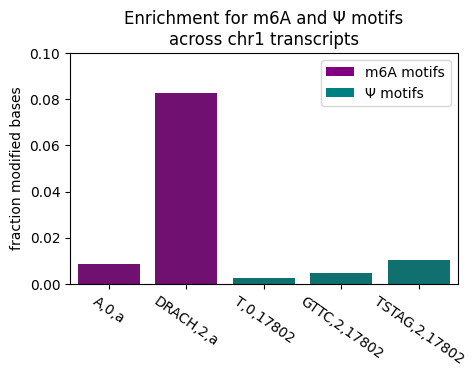

Loading data:   0%|          | 0/1 [00:00<?, ?it/s]

Loading data:   0%|          | 0/1 [00:00<?, ?it/s]

Loading data:   0%|          | 0/1 [00:00<?, ?it/s]

Loading data:   0%|          | 0/1 [00:00<?, ?it/s]

Loading data:   0%|          | 0/1 [00:00<?, ?it/s]

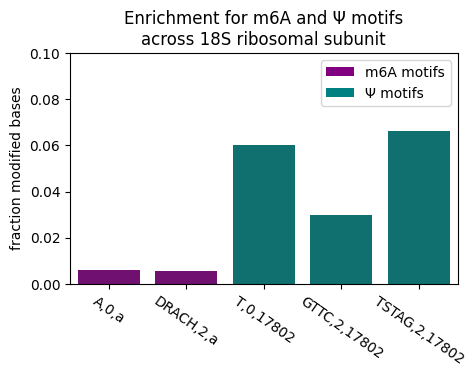

In [37]:
# fig, ax = plt.subplots(figsize=(10,4))
# plot_enrichment.by_modification(
#     mod_file_name=chr1_R_pileup,
#     regions="chr1:0-248_387_328",
#     motifs=["T,0,17802","GTTC,2,17802","TSTAG,2,17802","A,0,a","DRACH,2,a",],
#     ax=ax,
# )
# plt.semilogy()
# plt.show()
# plot_enrichment_profile.by_modification(
#     mod_file_name=chr1_R_pileup,
#     regions="chr1:0-248_387_328",
#     motifs=["T,0,17802","GTTC,2,17802","TSTAG,2,17802","A,0,a","DRACH,2,a",],
# )
from matplotlib.patches import Patch
names_list = ["chr1_transcripts", "18S ribosomal subunit", "all rRNA genes"]
RRNA_18S = "chrR:12996-14864"
RRNA_28S = "chrR:17259-22309"
RRNA_5_8S = "chrR:15935-16091"
RRNA_all = "chrR:0-44837"
regions_list = ["chr1:0-248_387_328", [RRNA_18S]]
for name,region in zip(names_list,regions_list):
    fig, ax = plt.subplots(figsize=(5,3))
    plot_enrichment.by_modification(
        mod_file_name=chr1_R_pileup,
        regions=region,
        motifs=["A,0,a","DRACH,2,a", "T,0,17802","GTTC,2,17802","TSTAG,2,17802"],
        ax=ax,
        palette={
            "A,0,a":"purple",
            "DRACH,2,a":"purple",
            "T,0,17802":"teal",
            "GTTC,2,17802":"teal",
            "TSTAG,2,17802":"teal",
            "TGTAR,2,17802":"teal",
        }
    )
    plt.title(f"Enrichment for m6A and Ψ motifs\nacross {name.replace('_',' ')}")
    plt.xticks(rotation=325)

    legend_elements = [
        Patch(facecolor='purple', label='m6A motifs'),
        Patch(facecolor='teal', label='Ψ motifs')
    ]
    ax.legend(handles=legend_elements)

    # plt.semilogy()
    plt.ylim(0.0,0.1)
    plt.show()
    fig.savefig(f"m6A_pseU_enrichment_across_{name}.svg", format="svg", bbox_inches='tight', dpi=300)


Loading data:   0%|          | 0/66619 [00:00<?, ?it/s]

Loading data:   0%|          | 0/66619 [00:00<?, ?it/s]

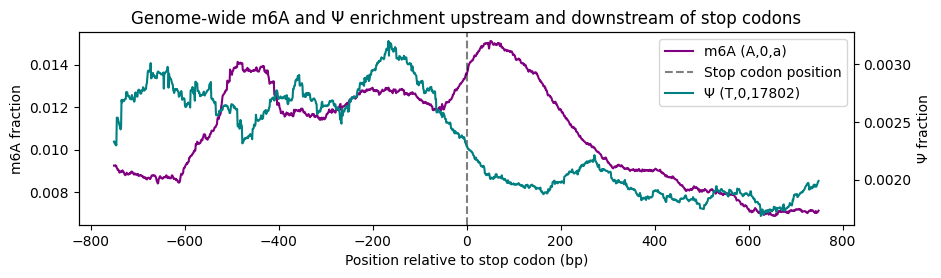

In [58]:
fig, ax1 = plt.subplots(figsize=(10,2.5))
ax2 = ax1.twinx()
plot_enrichment_profile.plot_enrichment_profile(
    mod_file_names=[stop_codon_pileup],
    motifs=["A,0,a"],
    regions_list=["/clusterfs/nilah/oberon/datasets/annotations/hs1_stop_codons_high_confidence.bed"],
    sample_names=["m6A (A,0,a)"],
    window_size=750,
    smooth_window=100,
    regions_5to3prime = True,
    palette = {
        "m6A (A,0,a)": "purple",
    },
    ax=ax1,
)
ax1.set_ylabel("m6A fraction")
plot_enrichment_profile.plot_enrichment_profile(
    mod_file_names=[stop_codon_pileup],
    motifs=["T,0,17802"],
    regions_list=["/clusterfs/nilah/oberon/datasets/annotations/hs1_stop_codons_high_confidence.bed"],
    sample_names=["Ψ (T,0,17802)"],
    window_size=750,
    smooth_window=100,
    regions_5to3prime = True,
    ax=ax2,
    palette = {
        "Ψ (T,0,17802)": "teal",
    },
)
ax2.set_ylabel("Ψ fraction")
ax1.axvline(x=0, color='black', linestyle='--', alpha=0.5, label='Stop codon position')
ax1.set_xlabel("Position relative to stop codon (bp)")
# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

# Remove the legend from ax2 if it exists
if ax2.get_legend() is not None:
    ax2.get_legend().remove()

plt.title("Genome-wide m6A and Ψ enrichment upstream and downstream of stop codons")
fig.savefig(f"m6A_pseU_profile_around_stop_codons.svg", format="svg", bbox_inches='tight', dpi=300)


In [5]:
# plot_enrichment_profile.by_modification(
#     mod_file_name=tss_pileup,
#     regions=tss_beds,
#     # motifs=["HRT,2,17802","DRACH,2,a"],
#     motifs=["DRACH,2,a","GTTC,2,17802","TSTAG,2,17802","A,0,a","T,0,17802"],
#     smooth_window=200,
#     window_size = 10_000,
#     regions_5to3prime = True,
# )
# plt.show()
# plot_depth_profile.by_modification(
#     mod_file_name=tss_pileup,
#     regions=tss_beds,
#     # motifs=["HRT,2,17802","DRACH,2,a"],
#     motifs=["DRACH,2,a","GTTC,2,17802","TSTAG,2,17802",],#"A,0,a","T,0,17802"],
#     smooth_window=200,
#     window_size = 10_000,
#     regions_5to3prime = True,
# )
# plt.show()

In [9]:
# region="chr11:9_113_463-10_113_463"
# region="chr11:9_530_000-9_534_000"
# region = "chr11:9_540_000-9_555_000"
# region = "chr11:9_650_000-9_670_000"
region = "chr11:9_530_000-9_550_000"
# region = "chr11:9_542_000-9_547_000"
# region = "chr11:9_690_000-9_710_000"
# region = "chr11:9_528_000-9_534_000"
# region = "chr11:9_580_000-9_600_000"
# region = "chr11:9_650_000-9_675_000"
# region = "chr11:9_655_000-9_680_000"
# fig = plot_read_browser.plot_read_browser(
#     mod_file_name=extract,
#     region = region,
#     motifs=["A,0,a","T,0,17802"],
#     sort_by="read_start",
#     thresh=0.0,
#     size=2,
#     colorscales={
#         "T,0,17802":["white","teal"],
#         "A,0,a":["white","purple"],
#         }
# )
# fig.update_layout(
#     width=1000,# these values are in pixels
#     height=600,    
#     # title={
#     #     'text': 'dRNA m6A and pseudouridine modifications',
#     #     'x': 0.5,
#     #     'xanchor': 'center',
#     #     'y': 0.75,  # Adjust the vertical position of the title
#     #     'yanchor': 'top',
#     #     'pad': {'b': 10} 
#     # },
#     xaxis_title='chr11 coordinate, t2t v2.0',
#     yaxis_title='reads'
# )

In [5]:
# fig=plot_read_browser.plot_read_browser(
#     mod_file_name=extract,
#     region = region,
#     motifs=["HRT,2,17802","DRACH,2,a"],
#     sort_by="read_start",
#     thresh=0.0,
#     size=2,
#     colorscales={
#         "HRT,2,17802":["white","teal"],
#         "DRACH,2,a":["white","purple"],
#         }
# )
# fig.update_layout(
#     width=1000,# these values are in pixels
#     height=600,    
#     # title={
#     #     'text': 'dRNA m6A and pseudouridine modifications',
#     #     'x': 0.5,
#     #     'xanchor': 'center',
#     #     'y': 0.75,  # Adjust the vertical position of the title
#     #     'yanchor': 'top',
#     #     'pad': {'b': 10} 
#     # },
#     xaxis_title='chr11 coordinate, t2t v2.0',
#     yaxis_title='reads'
# )

In [6]:
# plot_read_browser.plot_read_browser(
#     mod_file_name=extract_fiber,
#     region = region,
#     motifs=["A,0"],
#     sort_by="collapse",
#     thresh=0.75,
# )

In [7]:
# plot_read_browser.plot_read_browser(
#     mod_file_name=extract_fiber,
#     region = region,
#     motifs=["CG,0"],
#     sort_by="collapse",
#     thresh=0.75,
# )

In [8]:
# plot_read_browser.plot_read_browser(
#     mod_file_name=extract_dimelo,
#     region = region,
#     motifs=["A,0","WCG,1"],
#     sort_by="collapse",
#     thresh=0.95,
# )

In [9]:
# plot_read_browser.plot_read_browser(
#     mod_file_name=extract_dimelo,
#     region = region,
#     motifs=["A,0"],
#     sort_by="collapse",
#     thresh=0.95,
# )

In [38]:
# # region = 'chr1:0-2000000'
# # region = "chr11:9_113_463-10_113_463"
# region = "chr11:9_113_000-10_113_000"

# plot_read_browser.plot_read_browser(
#     mod_file_name=psmb2_extract,
#     # region = "chr1:35_466_000-35_466_400",
#     region = f"chr1:{35466152}-{35504550}",
#     # motifs=["HRT,2,17802","DRACH,2,a"],
#     motifs = ["DRACH,2,a","GTTC,2,17802"],
#     sort_by="read_start",
#     span_full_window=True,
#     thresh=0.9,
#     # size=2,
#     colorscales={
#         "DRACH,2,a":["white","purple"],
#         "T,0,17802":["white","teal"],
#         "A,0,a":["white","purple"],
#         "GTTC,2,17802":["white","teal"],
#         "TSTAG,2,17802":["white","green"],
#         },
# )
# fig.update_layout(
#     width=500,# these values are in pixels
#     height=1000,    
#     title={
#         'text': "PSMB2 full gene body",
#         'x': 0.5,
#         'xanchor': 'center',
#         'y': 0.75,  # Adjust the vertical position of the title
#         'yanchor': 'top',
#         'pad': {'b': 10} 
#     },
#     xaxis_title='chr1 coordinate, t2t v2.0',
#     yaxis_title='reads',
#     font=dict(color='black')
# )

In [37]:
# plot_read_browser.plot_read_browser(
#     mod_file_name=psmb2_extract,
#     region = "chr1:35_466_000-35_466_400",
#     # motifs=["HRT,2,17802","DRACH,2,a"],
#     motifs = ["A,0,a","T,0,17802"],
#     sort_by="read_start",
#     thresh=0.98,
#     # size=2,
#     colorscales={
#         "DRACH,2,a":["white","purple"],
#         "T,0,17802":["white","teal"],
#         "A,0,a":["white","purple"],
#         "GTTC,2,17802":["white","teal"],
#         "TSTAG,2,17802":["white","green"],
#         },
# )

In [36]:
# plot_depth_profile.by_modification(
#     mod_file_name=psmb2_pileup,
#     regions=PSMB2,
#     # motifs=["HRT,2,17802","DRACH,2,a"],
#     motifs=["A,0,a","T,0,17802"],
#     window_size = 500_000,
#     smooth_window=1000,
#     alpha=0.5,
#     # relative=False,
# )
# plt.show()
# plot_enrichment_profile.by_modification(
#     mod_file_name=psmb2_pileup,
#     regions=PSMB2,
#     # motifs=["HRT,2,17802","DRACH,2,a"],
#     motifs=["A,0,a","T,0,17802"],
#     smooth_window=1000,
#     window_size = 500_000,
#     alpha=0.5,
#     relative=False,
# )
# plt.show()

In [35]:
# plot_read_browser.plot_read_browser(
#     mod_file_name=rrna_extract,
#     region = "chrR:13100-14300",
#     # motifs=["HRT,2,17802","DRACH,2,a"],
#     motifs = ["DRACH,2,a","GTTC,2,17802","TSTAG,2,17802"],
#     sort_by="read_start",
#     thresh=0.98,
#     span_full_window=True,
#     # size=2,
#     colorscales={
#         "GTTC,2,17802":["white","teal"],
#         "TSTAG,2,17802":["white","green"],
#         "DRACH,2,a":["white","purple"],
#         "T,0,17802":["white","teal"],
#         "A,0,a":["white","purple"],
#         },
# )

In [21]:
fig = plot_read_browser.plot_read_browser(
    mod_file_name=rrna_extract,
    # region = f"chrR:{12996+10}-{14864-00}",
    region = f"chrR:{12996-2000}-{14864+2000}",
    # motifs=["HRT,2,17802","DRACH,2,a"],
    motifs = ["A,0,a","T,0,17802"],
    sort_by=("read_length","desc"),
    thresh=0.9,
    # span_full_window=True,
    # size=2,
    colorscales={
        "GTTC,2,17802":["white","teal"],
        "TSTAG,2,17802":["white","green"],
        "DRACH,2,a":["white","purple"],
        "T,0,17802":["white","teal"],
        "A,0,a":["white","purple"],
        },
)
fig.update_layout(
    width=900,# these values are in pixels
    height=300,    
    title={
        'text': "dRNA reads aligned to 18S rRNA gene body and flanking regions",
        'x': 0.5,
        'xanchor': 'center',
        'y': 0.75,  # Adjust the vertical position of the title
        'yanchor': 'top',
        'pad': {'b': 10} 
    },
    xaxis_title='chrR coordinates, hs1-rDNA v1.0',
    yaxis_title='reads',
    font=dict(color='black')
)
import plotly.graph_objects as go

# Define your regions (from the BED file data you provided)
regions = [
    {'start': 9339, 'end': 12995, 'label': "5' ETS"},
    {'start': 12996, 'end': 14864, 'label': '18S'},
    {'start': 14865, 'end': 15934, 'label': 'ITS1'},
    {'start': 15935, 'end': 16091, 'label': '5.8S'},
    {'start': 16092, 'end': 17258, 'label': 'ITS2'},
]

# Add a horizontal line spanning all regions at the top
fig.add_shape(
    type="line",
    x0=regions[0]['start'],
    x1=regions[-1]['end'],
    y0=1.02,  # Just above the plot
    y1=1.02,
    yref="paper",
    line=dict(color="black", width=2),
)

# Add vertical tick marks at region boundaries - much taller
for i, region in enumerate(regions):
    # Tick at start of region
    fig.add_shape(
        type="line",
        x0=region['start'],
        x1=region['start'],
        y0=1.02,
        y1=1.09,  # Much taller tick (increased from 0.02 to 0.04 height)
        yref="paper",
        line=dict(color="black", width=2),
    )
    # Tick at end of last region
    if i == len(regions) - 1:
        fig.add_shape(
            type="line",
            x0=region['end'],
            x1=region['end'],
            y0=1.02,
            y1=1.09,
            yref="paper",
            line=dict(color="black", width=2),
        )

# Add text annotations above the line
for region in regions:
    mid_point = (region['start'] + region['end']) / 2
    fig.add_annotation(
        x=mid_point,
        y=1.08,  # Above the ticks
        yref="paper",
        text=region['label'],
        showarrow=False,
        font=dict(size=11, color="black", family="Arial"),
        xanchor="center",
        yanchor="bottom"
    )

# Add label on the left indicating these are annotations
fig.add_annotation(
    x=0,
    xref="paper",
    y=1.055,  # Centered vertically with the annotation track
    yref="paper",
    text="rRNA<br>annotations",
    showarrow=False,
    font=dict(size=11, color="black", family="Arial"),
    xanchor="right",
    yanchor="middle",
    xshift=-10  # Add a bit of space from the left edge
)

# Update layout to make room at the top
fig.update_layout(
    margin=dict(t=120),  # Increase top margin
)

fig.write_image(f"18SRNA_flanking_read_browser.svg", format="svg")
display(fig)

In [22]:
fig = plot_read_browser.plot_read_browser(
    mod_file_name=rrna_extract,
    region = f"chrR:{12996+10}-{14864-00}",
    # motifs=["HRT,2,17802","DRACH,2,a"],
    motifs = ["A,0,a","T,0,17802"],
    sort_by="read_end",
    thresh=0.9,
    width=0.5,
    span_full_window=True,
    # size=2,
    colorscales={
        "GTTC,2,17802":["white","teal"],
        "TSTAG,2,17802":["white","green"],
        "DRACH,2,a":["white","purple"],
        "T,0,17802":["white","teal"],
        "A,0,a":["white","purple"],
        },
)
fig.update_layout(
    width=900,# these values are in pixels
    height=350,    
    title={
        'text': "dRNA reads spanning the entire 18S rRNA gene body",
        'x': 0.5,
        'xanchor': 'center',
        'y': 0.8,  # Adjust the vertical position of the title
        'yanchor': 'top',
        'pad': {'b': 10} 
    },
    xaxis_title='chrR coordinate, hs1-rDNA v1.0',
    yaxis_title='reads',
    font=dict(color='black')
)
fig.write_image(f"18SRNA_spanning_read_browser.svg", format="svg")
display(fig)